# Testing de modelos en set de test

Este notebook permite evaluar y comparar modelos de distintos algoritmos
guardados como pipelines del proyecto (LightGBM, RandomForest, XGBoost, Árbol de Decisiones).

## Flujo

1. Detectar o elegir estudios/modelos por algoritmo.
2. Cargar test en formato sparse desde `datasets/final_sparse`.
3. Evaluar cada modelo y comparar metricas globales.
4. Ver matriz de confusion y reporte por clase para un algoritmo.

In [1]:
from pathlib import Path
from typing import Dict, Optional, Any
import json

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sparse_dataset import load_sparse_split, load_feature_columns

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ajustes base
ROOT = Path('.').resolve()
DATASET_DIR = ROOT / 'datasets'
SPARSE_DIR = DATASET_DIR / 'final_sparse'
TEST_SPLIT = 'test'
CLASS_MAP_PATH = DATASET_DIR / 'class_mapping.json'
OPTUNA_DB = 'sqlite:///optuna.sqlite3'

ALGO_DIRS = {
    'lightgbm': ROOT / 'models' / 'lgbm',
    'randomforest': ROOT / 'models' / 'randomforest',
    'xgboost': ROOT / 'models' / 'xgboost',
    'decision_tree': ROOT / 'models' / 'decision_tree',
}

STUDY_PREFIXES = {
    'lightgbm': ['LGBM_', 'lightgbm_'],
    'randomforest': ['RF_', 'randomforest_'],
    'xgboost': ['xgboost_', 'XGBOOST_'],
    'decision_tree': ['dt_', 'decision_tree_'],
}

print('ROOT:', ROOT)
print('SPARSE_DIR exists:', SPARSE_DIR.exists())
print('test_X exists:', (SPARSE_DIR / 'test_X.npz').exists())
print('test_y exists:', (SPARSE_DIR / 'test_y.npy').exists())

ROOT: /home/francisco/maestria/trabajo final/tf-austral
SPARSE_DIR exists: True
test_X exists: True
test_y exists: True


In [3]:
def invert_class_mapping(path: Path) -> Dict[int, str]:
    if not path.exists():
        return {}
    raw = json.loads(path.read_text(encoding='utf-8'))
    return {int(v): str(k) for k, v in raw.items()}


def list_studies_by_algo(storage_url: str) -> Dict[str, list]:
    studies = optuna.get_all_study_summaries(storage=storage_url)
    result = {k: [] for k in ALGO_DIRS.keys()}

    for s in studies:
        for algo, prefixes in STUDY_PREFIXES.items():
            if any(s.study_name.startswith(p) for p in prefixes):
                result[algo].append(s)
                break

    for algo in result:
        result[algo] = sorted(
            result[algo],
            key=lambda x: (x.best_trial.value if x.best_trial else -10**9),
            reverse=True,
        )

    return result


def strip_prefix(study_name: str, algo: str) -> str:
    for prefix in STUDY_PREFIXES[algo]:
        if study_name.startswith(prefix):
            return study_name[len(prefix):]
    return study_name


def find_model_path(algo: str, short_study_name: str) -> Optional[Path]:
    model_root = ALGO_DIRS[algo]
    if not model_root.exists():
        return None

    expected = model_root / short_study_name / f'model_{short_study_name}.pkl'
    if expected.exists():
        return expected
    
    # Para decision_tree_base o decision_tree con base_model, buscar model_base_*.pkl
    if (algo == 'decision_tree' or algo == 'decision_tree_base') and short_study_name == 'base_model':
        expected_base = model_root / short_study_name / f'model_base_{short_study_name}.pkl'
        if expected_base.exists():
            return expected_base

    candidates = sorted(model_root.rglob('model_*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        return None

    for c in candidates:
        if short_study_name.lower() in c.stem.lower():
            return c

    return candidates[0]


def choose_study_and_model(algo: str, manual_short_study: Optional[str], studies_cache: Dict[str, list]):
    if manual_short_study:
        model_path = find_model_path(algo, manual_short_study)
        return manual_short_study, model_path

    studies = studies_cache.get(algo, [])
    if studies:
        short_study = strip_prefix(studies[0].study_name, algo)
        model_path = find_model_path(algo, short_study)
        return short_study, model_path

    model_root = ALGO_DIRS[algo]
    if not model_root.exists():
        return None, None

    candidates = sorted(model_root.rglob('model_*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        return None, None

    last = candidates[0]
    short_study = last.stem.replace('model_', '', 1).replace('model_base_', '', 1)
    return short_study, last

In [8]:
# Agregar decision_tree_base a ALGO_DIRS PRIMERO
ALGO_DIRS['decision_tree_base'] = ALGO_DIRS['decision_tree']
STUDY_PREFIXES['decision_tree_base'] = ['dt_base_', 'base_model_']

# Luego ejecutar la búsqueda de estudios
studies_cache = list_studies_by_algo(OPTUNA_DB)

# Opcional: fijar estudios manualmente (None = autodeteccion)
study_name = "final"
MANUAL_STUDIES = {
    'lightgbm': "LGBM_final",
    'randomforest': "RF_final",
    'xgboost': "xgboost_final",
    'decision_tree': "model_final",
    'decision_tree_base': "base_model",
}

for algo in ALGO_DIRS.keys():
    best = studies_cache.get(algo, [])
    msg = best[0].study_name if best else 'sin estudio en optuna'
    print(f'{algo:20s} -> {msg}')

lightgbm             -> LGBM_final
randomforest         -> RF_final
xgboost              -> xgboost_final
decision_tree        -> dt_modelo_completo_final
decision_tree_base   -> sin estudio en optuna


In [9]:
if not SPARSE_DIR.exists():
    raise FileNotFoundError(f'No existe {SPARSE_DIR}')

X_test, y_test_np = load_sparse_split(DATASET_DIR, TEST_SPLIT)
if not isinstance(X_test, csr_matrix):
    X_test = X_test.tocsr()

feature_columns = load_feature_columns(DATASET_DIR)
if X_test.shape[1] != len(feature_columns):
    raise ValueError(
        f'Dimension inconsistente: X_test tiene {X_test.shape[1]} columnas y feature_columns tiene {len(feature_columns)}'
    )

y_test = pd.Series(y_test_np).astype(int)
inv_mapping = invert_class_mapping(CLASS_MAP_PATH)

print('X_test shape:', X_test.shape)
print('y_test clases:', y_test.nunique())
print('feature_columns:', len(feature_columns))

X_test shape: (25357, 3172)
y_test clases: 13
feature_columns: 3172


In [11]:
def evaluate_pipeline(algo: str, model_path: Path, X: Any, y: pd.Series):
    model = joblib.load(model_path)
    y_pred = pd.Series(np.asarray(model.predict(X)).ravel()).astype(int)

    metrics = {
        'algorithm': algo,
        'model_path': str(model_path),
        'accuracy': accuracy_score(y, y_pred),
        'kappa': cohen_kappa_score(y, y_pred),
        'f1_macro': f1_score(y, y_pred, average='macro', zero_division=0),
        'precision_macro': precision_score(y, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, y_pred, average='macro', zero_division=0),
    }

    labels = sorted(set(y.unique()).union(set(y_pred.unique())))
    cm = confusion_matrix(y, y_pred, labels=labels)

    return metrics, y_pred, labels, cm


def evaluate_pipeline_decision_tree_base(model_path: Path):
    """
    Evaluación especial para decision_tree_base que carga datos CSV y aplica el mismo preprocessing.
    Retorna las mismas métricas que evaluate_pipeline.
    """
    from preprocessing import ClassToInt, imputarNA, aplicar_ohe_splits
    
    try:
        # Columnas necesarias (sin procesamiento de texto)
        REQUIRED_COLS = [
            "tipo_comp", "nro_cuenta", "nro_entidad", "desc_entidad", "tipo_pres",
            "tipo_reg", "clase_reg", "cod", "fuente_fin", "descripcion", "tipo_cta",
            "cod_bco", "Class"
        ]
        OHE_COLS = ['tipo_comp', 'tipo_reg', 'clase_reg', 'tipo_cta', 'tipo_pres', 'desc_entidad', 'cod_bco', 'cod']
        SEED = 12345
        
        # Cargar CSV
        dfs = {
            "train": pd.read_csv(DATASET_DIR / "2022-2023-2024.csv"),
            "val": pd.read_csv(DATASET_DIR / "2025-1.csv"),
            "test": pd.read_csv(DATASET_DIR / "2025-2.csv"),
        }
        
        # Seleccionar columnas
        for split in dfs:
            dfs[split] = dfs[split][REQUIRED_COLS]
        
        # Imputar NA's
        for split in dfs:
            dfs[split] = imputarNA(dfs[split])
        
        # Convertir Class a entero
        dfs["train"], class_mapping = ClassToInt(dfs["train"], class_mapping=None)
        dfs["val"], _ = ClassToInt(dfs["val"], class_mapping=class_mapping)
        dfs["test"], _ = ClassToInt(dfs["test"], class_mapping=class_mapping)
        
        # Descartar 'descripcion'
        for split in dfs:
            dfs[split] = dfs[split].drop("descripcion", axis=1)
        
        # OneHotEncoding
        dfs["train"], dfs["val"], dfs["test"] = aplicar_ohe_splits(
            dfs["train"], dfs["val"], dfs["test"],
            columnas=OHE_COLS
        )
        
        # Separar features y target
        X_train = dfs["train"].drop("target", axis=1)
        y_train = dfs["train"]["target"]
        
        X_val = dfs["val"].drop("target", axis=1)
        y_val = dfs["val"]["target"]
        
        X_test = dfs["test"].drop("target", axis=1)
        y_test = dfs["test"]["target"]
        
        # Cargar modelo
        model = joblib.load(model_path)
        y_pred = pd.Series(np.asarray(model.predict(X_test)).ravel()).astype(int)
        
        metrics = {
            'algorithm': 'decision_tree_base',
            'model_path': str(model_path),
            'accuracy': accuracy_score(y_test, y_pred),
            'kappa': cohen_kappa_score(y_test, y_pred),
            'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        }
        
        labels = sorted(set(y_test.unique()).union(set(y_pred.unique())))
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        
        return metrics, y_pred, labels, cm, y_test
        
    except Exception as e:
        print(f'[ERROR] evaluate_pipeline_decision_tree_base: {e}')
        raise

In [12]:
def evaluate_pipeline(algo: str, model_path: Path, X: Any, y: pd.Series):
    model = joblib.load(model_path)
    y_pred = pd.Series(np.asarray(model.predict(X)).ravel()).astype(int)

    metrics = {
        'algorithm': algo,
        'model_path': str(model_path),
        'accuracy': accuracy_score(y, y_pred),
        'kappa': cohen_kappa_score(y, y_pred),
        'f1_macro': f1_score(y, y_pred, average='macro', zero_division=0),
        'precision_macro': precision_score(y, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, y_pred, average='macro', zero_division=0),
    }

    labels = sorted(set(y.unique()).union(set(y_pred.unique())))
    cm = confusion_matrix(y, y_pred, labels=labels)

    return metrics, y_pred, labels, cm


def evaluate_pipeline_decision_tree_base(model_path: Path):
    """
    Evaluación especial para decision_tree_base que carga datos CSV y aplica el mismo preprocessing.
    Retorna las mismas métricas que evaluate_pipeline.
    """
    from preprocessing import ClassToInt, imputarNA, aplicar_ohe_splits
    
    try:
        # Columnas necesarias (sin procesamiento de texto)
        REQUIRED_COLS = [
            "tipo_comp", "nro_cuenta", "nro_entidad", "desc_entidad", "tipo_pres",
            "tipo_reg", "clase_reg", "cod", "fuente_fin", "descripcion", "tipo_cta",
            "cod_bco", "Class"
        ]
        OHE_COLS = ['tipo_comp', 'tipo_reg', 'clase_reg', 'tipo_cta', 'tipo_pres', 'desc_entidad', 'cod_bco', 'cod']
        SEED = 12345
        
        # Cargar CSV
        dfs = {
            "train": pd.read_csv(DATASET_DIR / "2022-2023-2024.csv"),
            "val": pd.read_csv(DATASET_DIR / "2025-1.csv"),
            "test": pd.read_csv(DATASET_DIR / "2025-2.csv"),
        }
        
        # Seleccionar columnas
        for split in dfs:
            dfs[split] = dfs[split][REQUIRED_COLS]
        
        # Imputar NA's
        for split in dfs:
            dfs[split] = imputarNA(dfs[split])
        
        # Convertir Class a entero
        dfs["train"], class_mapping = ClassToInt(dfs["train"], class_mapping=None)
        dfs["val"], _ = ClassToInt(dfs["val"], class_mapping=class_mapping)
        dfs["test"], _ = ClassToInt(dfs["test"], class_mapping=class_mapping)
        
        # Descartar 'descripcion'
        for split in dfs:
            dfs[split] = dfs[split].drop("descripcion", axis=1)
        
        # OneHotEncoding
        dfs["train"], dfs["val"], dfs["test"] = aplicar_ohe_splits(
            dfs["train"], dfs["val"], dfs["test"],
            columnas=OHE_COLS
        )
        
        # Separar features y target
        X_train = dfs["train"].drop("target", axis=1)
        y_train = dfs["train"]["target"]
        
        X_val = dfs["val"].drop("target", axis=1)
        y_val = dfs["val"]["target"]
        
        X_test = dfs["test"].drop("target", axis=1)
        y_test = dfs["test"]["target"]
        
        # Cargar modelo
        model = joblib.load(model_path)
        y_pred = pd.Series(np.asarray(model.predict(X_test)).ravel()).astype(int)
        
        metrics = {
            'algorithm': 'decision_tree_base',
            'model_path': str(model_path),
            'accuracy': accuracy_score(y_test, y_pred),
            'kappa': cohen_kappa_score(y_test, y_pred),
            'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        }
        
        labels = sorted(set(y_test.unique()).union(set(y_pred.unique())))
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        
        return metrics, y_pred, labels, cm, y_test
        
    except Exception as e:
        print(f'[ERROR] evaluate_pipeline_decision_tree_base: {e}')
        raise


In [13]:
# Crear mapeo de números a nombres de clases
with open(CLASS_MAP_PATH, 'r') as f:
    class_mapping = json.load(f)
class_names_dict = {v: k for k, v in class_mapping.items()}

results_rows = []
predictions_by_algo = {}
cm_by_algo = {}
labels_by_algo = {}
y_test_by_algo = {}  # Almacenar y_test por algoritmo

for algo in ALGO_DIRS.keys():
    short_study, model_path = choose_study_and_model(algo, MANUAL_STUDIES.get(algo), studies_cache)

    if model_path is None or not Path(model_path).exists():
        print(f'[SKIP] {algo}: no se encontro modelo para evaluar')
        continue

    print(f'[RUN ] {algo}: {short_study} -> {model_path}')
    
    # Caso especial para decision_tree_base
    if algo == 'decision_tree_base':
        try:
            metrics, y_pred, labels, cm, y_test_special = evaluate_pipeline_decision_tree_base(Path(model_path))
            y_test_to_use = y_test_special
        except Exception as e:
            print(f'[ERROR] decision_tree_base: {e}')
            continue
    else:
        metrics, y_pred, labels, cm = evaluate_pipeline(algo, Path(model_path), X_test, y_test)
        y_test_to_use = y_test
    
    metrics['study_name'] = short_study

    results_rows.append(metrics)
    predictions_by_algo[algo] = y_pred
    cm_by_algo[algo] = cm
    labels_by_algo[algo] = labels
    y_test_by_algo[algo] = y_test_to_use

results_df = pd.DataFrame(results_rows)
if results_df.empty:
    raise RuntimeError('No hubo modelos evaluados. Revisar MANUAL_STUDIES o carpetas de models/.')

results_df = results_df.sort_values(['kappa', 'accuracy'], ascending=False).reset_index(drop=True)

# Mostrar resultados con mejor formato
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("\n" + "="*100)
print("RESULTADOS DE EVALUACIÓN EN TEST SET")
print("="*100)
print(results_df[['algorithm', 'study_name', 'accuracy', 'kappa', 'f1_macro', 'precision_macro', 'recall_macro']].to_string(index=True))
print("="*100)
results_df

[RUN ] lightgbm: LGBM_final -> /home/francisco/maestria/trabajo final/tf-austral/models/lgbm/final/model_final.pkl
[LightGBM] [Warning] Unknown parameter: verbose_eval


/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[RUN ] randomforest: RF_final -> /home/francisco/maestria/trabajo final/tf-austral/models/randomforest/final/model_final.pkl
[RUN ] xgboost: xgboost_final -> /home/francisco/maestria/trabajo final/tf-austral/models/xgboost/final/model_final.pkl
[RUN ] decision_tree: model_final -> /home/francisco/maestria/trabajo final/tf-austral/models/decision_tree/final/model_final.pkl
[RUN ] decision_tree_base: base_model -> /home/francisco/maestria/trabajo final/tf-austral/models/decision_tree/base_model/model_base_base_model.pkl


/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'es_core_news_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 0
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 0
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 1455
   - Clases encontradas (train): ['GF', 'PTE', 'Sueldos', 'Viaticos', 'Proveedores', 'FF', 'Servicios', 'Retenciones de sueldo', 'Honorarios', 'Contratistas', 'Alquileres', 'CCF', 'Subsidios']
   - Usando mapeo de clases existente: {'GF': 0, 'PTE': 1, 'Sueldos': 2, 'Viaticos': 3, 'Proveedores': 4, 'FF': 5, 'Servicios': 6, 'Retenciones de sueldo': 7, 'Honorarios': 8, 'Contratistas': 9, 'Alquileres': 10, 'CCF': 11, 'Subsidios': 12}
   - Usando mapeo de clases existente: {'GF': 0, 'PTE': 1, 'Sueldos': 2, 'Viaticos': 3, 'Proveedores': 4, 'FF': 5, 'Servicios': 6, 'Retenciones de sueldo': 7, 'Honorarios': 8, 'Contratistas': 9, 'Alquileres': 10, 'CCF': 11, 'Subsidios': 12}
   - Columnas para OneHotEncoding: ['tipo_comp', 'tipo_reg', 'clase_reg', 'tipo_cta', 'tipo_pres', 'desc_entidad', 'cod_bco', 'cod']
   - OneHotEncoding c

,algorithm,model_path,accuracy,kappa,f1_macro,precision_macro,recall_macro,study_name
0,xgboost,/home/francisco/maestria/trabajo final/tf-aust...,0.966794,0.958212,0.951013,0.950625,0.952794,xgboost_final
1,lightgbm,/home/francisco/maestria/trabajo final/tf-aust...,0.966715,0.958138,0.947615,0.947134,0.950387,LGBM_final
2,randomforest,/home/francisco/maestria/trabajo final/tf-aust...,0.958276,0.947469,0.938799,0.944224,0.937630,RF_final
3,decision_tree,/home/francisco/maestria/trabajo final/tf-aust...,0.927752,0.908138,0.909798,0.927360,0.897849,model_final
4,decision_tree_base,/home/francisco/maestria/trabajo final/tf-aust...,0.788382,0.720672,0.613243,0.689680,0.584667,base_model


Algoritmo seleccionado: xgboost


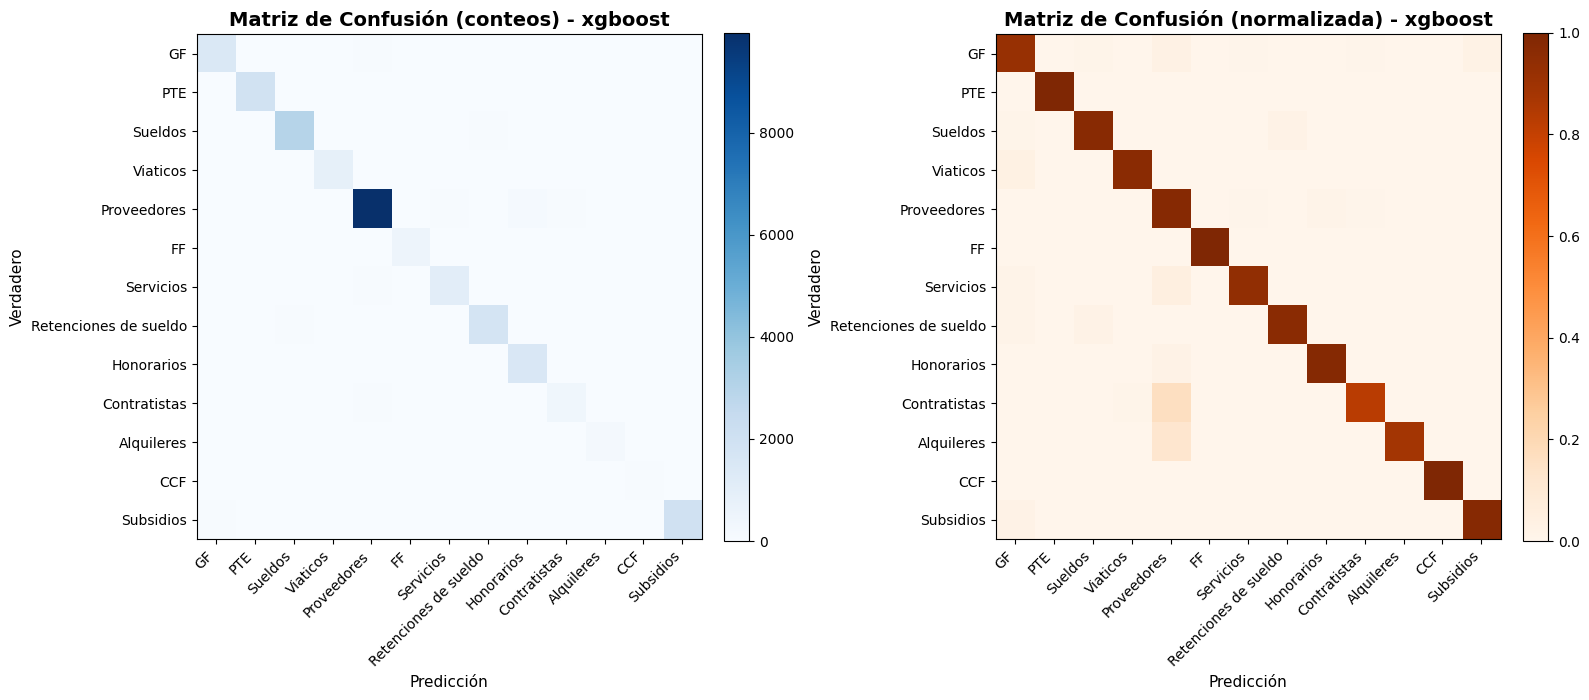


REPORTE DE CLASIFICACIÓN - XGBOOST
                       precision    recall  f1-score       support
GF                      0.905934  0.921053  0.913431   1558.000000
PTE                     1.000000  1.000000  1.000000   1885.000000
Sueldos                 0.978375  0.966030  0.972163   3091.000000
Viaticos                0.983778  0.962585  0.973066    882.000000
Proveedores             0.976183  0.975419  0.975801  10211.000000
FF                      1.000000  1.000000  1.000000    473.000000
Servicios               0.942081  0.940379  0.941230   1107.000000
Retenciones de sueldo   0.961075  0.963716  0.962394   1819.000000
Honorarios              0.923926  0.976654  0.949559   1542.000000
Contratistas            0.866370  0.825902  0.845652    471.000000
Alquileres              0.976959  0.879668  0.925764    241.000000
CCF                     0.862745  1.000000  0.926316     44.000000
Subsidios               0.980703  0.974914  0.977800   2033.000000
accuracy                0.

,precision,recall,f1-score,support
GF,0.905934,0.921053,0.913431,1558.000000
PTE,1.000000,1.000000,1.000000,1885.000000
Sueldos,0.978375,0.966030,0.972163,3091.000000
Viaticos,0.983778,0.962585,0.973066,882.000000
Proveedores,0.976183,0.975419,0.975801,10211.000000
FF,1.000000,1.000000,1.000000,473.000000
Servicios,0.942081,0.940379,0.941230,1107.000000
Retenciones de sueldo,0.961075,0.963716,0.962394,1819.000000
Honorarios,0.923926,0.976654,0.949559,1542.000000
Contratistas,0.866370,0.825902,0.845652,471.000000


In [14]:
# Elegir algoritmo para analisis detallado
ALGO_DETAIL = results_df.loc[0, 'algorithm']
print('Algoritmo seleccionado:', ALGO_DETAIL)

y_pred_detail = predictions_by_algo[ALGO_DETAIL]
y_test_detail = y_test_by_algo[ALGO_DETAIL]
labels = labels_by_algo[ALGO_DETAIL]
cm = cm_by_algo[ALGO_DETAIL]

# Usar nombres de clases del mapping
label_names = [class_names_dict.get(int(lbl), f"Clase_{lbl}") for lbl in labels]

cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

im0 = ax[0].imshow(cm, cmap='Blues')
ax[0].set_title(f'Matriz de Confusión (conteos) - {ALGO_DETAIL}', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=11)
ax[0].set_ylabel('Verdadero', fontsize=11)
ax[0].set_xticks(np.arange(len(label_names)))
ax[0].set_yticks(np.arange(len(label_names)))
ax[0].set_xticklabels(label_names, rotation=45, ha='right', fontsize=10)
ax[0].set_yticklabels(label_names, fontsize=10)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(cm_norm, cmap='Oranges', vmin=0, vmax=1)
ax[1].set_title(f'Matriz de Confusión (normalizada) - {ALGO_DETAIL}', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=11)
ax[1].set_ylabel('Verdadero', fontsize=11)
ax[1].set_xticks(np.arange(len(label_names)))
ax[1].set_yticks(np.arange(len(label_names)))
ax[1].set_xticklabels(label_names, rotation=45, ha='right', fontsize=10)
ax[1].set_yticklabels(label_names, fontsize=10)
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Reporte de clasificación con nombres de clases
report = classification_report(y_test_detail, y_pred_detail, target_names=label_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T

print("\n" + "="*80)
print(f"REPORTE DE CLASIFICACIÓN - {ALGO_DETAIL.upper()}")
print("="*80)
print(report_df.to_string())
print("="*80)

report_df

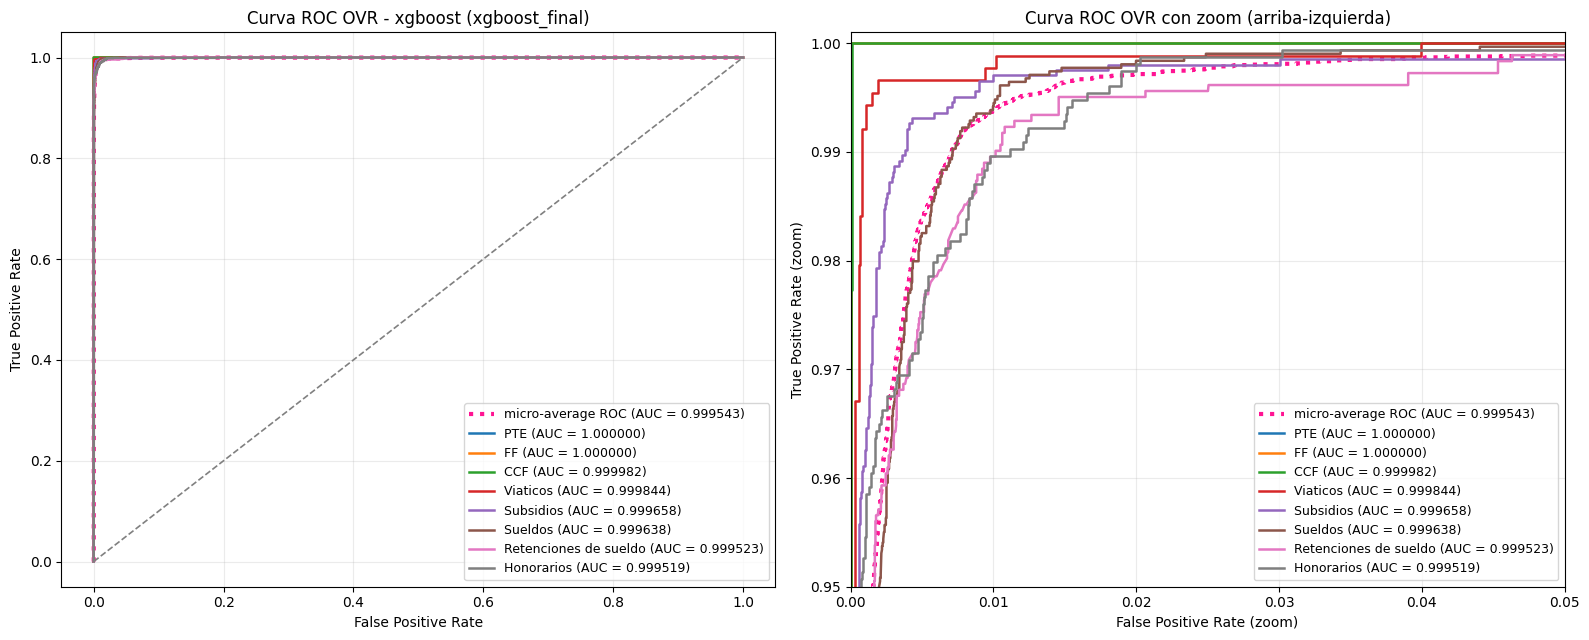


AUC micro-average: 0.999543

AUC por Clase:
                clase      auc
                  PTE 1.000000
                   FF 1.000000
                  CCF 0.999982
             Viaticos 0.999844
            Subsidios 0.999658
              Sueldos 0.999638
Retenciones de sueldo 0.999523
           Honorarios 0.999519
            Servicios 0.999236
           Alquileres 0.998715
          Proveedores 0.998523
                   GF 0.997114
         Contratistas 0.996999


In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Cargar mapeo de clases
CLASS_MAP_PATH = DATASET_DIR / 'class_mapping.json'
with open(CLASS_MAP_PATH, 'r') as f:
    class_mapping = json.load(f)
class_names_dict = {v: k for k, v in class_mapping.items()}

# Recuperar el modelo elegido en el ranking
algo_roc = ALGO_DETAIL
short_study_roc, model_path_roc = choose_study_and_model(
    algo_roc, MANUAL_STUDIES.get(algo_roc), studies_cache
)

if model_path_roc is None or not Path(model_path_roc).exists():
    raise FileNotFoundError(f'No se encontro modelo para ROC: {algo_roc}')

model_roc = joblib.load(model_path_roc)

# Usar el y_test correcto para este modelo
y_test_roc = y_test_by_algo[algo_roc]

# Preparar X_test (diferente según el modelo)
if algo_roc == 'decision_tree_base':
    from preprocessing import ClassToInt, imputarNA, aplicar_ohe_splits
    REQUIRED_COLS = [
        "tipo_comp", "nro_cuenta", "nro_entidad", "desc_entidad", "tipo_pres",
        "tipo_reg", "clase_reg", "cod", "fuente_fin", "descripcion", "tipo_cta",
        "cod_bco", "Class"
    ]
    OHE_COLS = ['tipo_comp', 'tipo_reg', 'clase_reg', 'tipo_cta', 'tipo_pres', 'desc_entidad', 'cod_bco', 'cod']
    
    dfs_roc = {
        "train": pd.read_csv(DATASET_DIR / "2022-2023-2024.csv"),
        "val": pd.read_csv(DATASET_DIR / "2025-1.csv"),
        "test": pd.read_csv(DATASET_DIR / "2025-2.csv"),
    }
    for split in dfs_roc:
        dfs_roc[split] = dfs_roc[split][REQUIRED_COLS]
    for split in dfs_roc:
        dfs_roc[split] = imputarNA(dfs_roc[split])
    dfs_roc["train"], class_mapping_roc = ClassToInt(dfs_roc["train"], class_mapping=None)
    dfs_roc["val"], _ = ClassToInt(dfs_roc["val"], class_mapping=class_mapping_roc)
    dfs_roc["test"], _ = ClassToInt(dfs_roc["test"], class_mapping=class_mapping_roc)
    for split in dfs_roc:
        dfs_roc[split] = dfs_roc[split].drop("descripcion", axis=1)
    dfs_roc["train"], dfs_roc["val"], dfs_roc["test"] = aplicar_ohe_splits(
        dfs_roc["train"], dfs_roc["val"], dfs_roc["test"],
        columnas=OHE_COLS
    )
    X_test_roc = dfs_roc["test"].drop("target", axis=1)
else:
    X_test_roc = X_test

if not hasattr(model_roc, 'predict_proba'):
    raise AttributeError(
        f'El modelo {algo_roc} no expone predict_proba, no se puede construir ROC.'
    )

y_score = np.asarray(model_roc.predict_proba(X_test_roc))
classes = np.unique(y_test_roc)

if y_score.ndim != 2 or y_score.shape[1] != len(classes):
    raise ValueError(
        f'Dimension inesperada en predict_proba: {y_score.shape}, clases esperadas={len(classes)}'
    )

# Ventana de zoom para resaltar diferencias finas
zoom_fpr_max = 0.05
zoom_tpr_min = 0.95

# ROC binaria (si hay dos clases)
if len(classes) == 2:
    positive_class = classes[1]
    positive_class_name = class_names_dict.get(int(positive_class), f"Clase_{positive_class}")
    y_true_bin = (y_test_roc.to_numpy() == positive_class).astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_score[:, 1])
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

    # Vista completa
    ax[0].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.6f})')
    ax[0].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'ROC completa - {algo_roc} ({short_study_roc})')
    ax[0].legend(loc='lower right')
    ax[0].grid(alpha=0.25)

    # Vista zoom
    ax[1].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.6f})')
    ax[1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[1].set_xlim(0.0, zoom_fpr_max)
    ax[1].set_ylim(zoom_tpr_min, 1.001)
    ax[1].set_xlabel('False Positive Rate (zoom)')
    ax[1].set_ylabel('True Positive Rate (zoom)')
    ax[1].set_title('ROC con zoom (arriba-izquierda)')
    ax[1].legend(loc='lower right')
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(f'AUC binaria ({positive_class_name}): {roc_auc:.6f}')

# ROC multiclase OVR: curvas por clase + micro-average
else:
    y_true_bin = label_binarize(y_test_roc.to_numpy(), classes=classes)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    top_n = min(8, len(classes))
    top_classes = sorted(classes, key=lambda c: roc_auc[int(np.where(classes == c)[0][0])], reverse=True)[:top_n]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))

    # Vista completa
    ax[0].plot(
        fpr['micro'],
        tpr['micro'],
        label=f"micro-average ROC (AUC = {roc_auc['micro']:.6f})",
        color='deeppink',
        linestyle=':',
        linewidth=3,
    )
    for cls in top_classes:
        idx = int(np.where(classes == cls)[0][0])
        class_name = class_names_dict.get(int(cls), f"Clase_{cls}")
        ax[0].plot(
            fpr[idx],
            tpr[idx],
            lw=1.8,
            label=f'{class_name} (AUC = {roc_auc[idx]:.6f})'
        )
    ax[0].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'Curva ROC OVR - {algo_roc} ({short_study_roc})')
    ax[0].legend(loc='lower right', fontsize=9)
    ax[0].grid(alpha=0.25)

    # Vista zoom
    ax[1].plot(
        fpr['micro'],
        tpr['micro'],
        label=f"micro-average ROC (AUC = {roc_auc['micro']:.6f})",
        color='deeppink',
        linestyle=':',
        linewidth=3,
    )
    for cls in top_classes:
        idx = int(np.where(classes == cls)[0][0])
        class_name = class_names_dict.get(int(cls), f"Clase_{cls}")
        ax[1].plot(
            fpr[idx],
            tpr[idx],
            lw=1.8,
            label=f'{class_name} (AUC = {roc_auc[idx]:.6f})'
        )
    ax[1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[1].set_xlim(0.0, zoom_fpr_max)
    ax[1].set_ylim(zoom_tpr_min, 1.001)
    ax[1].set_xlabel('False Positive Rate (zoom)')
    ax[1].set_ylabel('True Positive Rate (zoom)')
    ax[1].set_title('Curva ROC OVR con zoom (arriba-izquierda)')
    ax[1].legend(loc='lower right', fontsize=9)
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    auc_rows = [
        {'clase': class_names_dict.get(int(cls), f"Clase_{cls}"), 'auc': float(roc_auc[i])}
        for i, cls in enumerate(classes)
    ]
    auc_df = pd.DataFrame(auc_rows).sort_values('auc', ascending=False).reset_index(drop=True)
    print(f"\nAUC micro-average: {roc_auc['micro']:.6f}")
    print("\nAUC por Clase:")
    print(auc_df.to_string(index=False))
    auc_df

[OK] lightgbm: 3172 features extraídas
[OK] randomforest: 3172 features extraídas
[OK] xgboost: 3172 features extraídas
[OK] decision_tree: 3172 features extraídas
[ERROR] decision_tree_base: All arrays must be of the same length


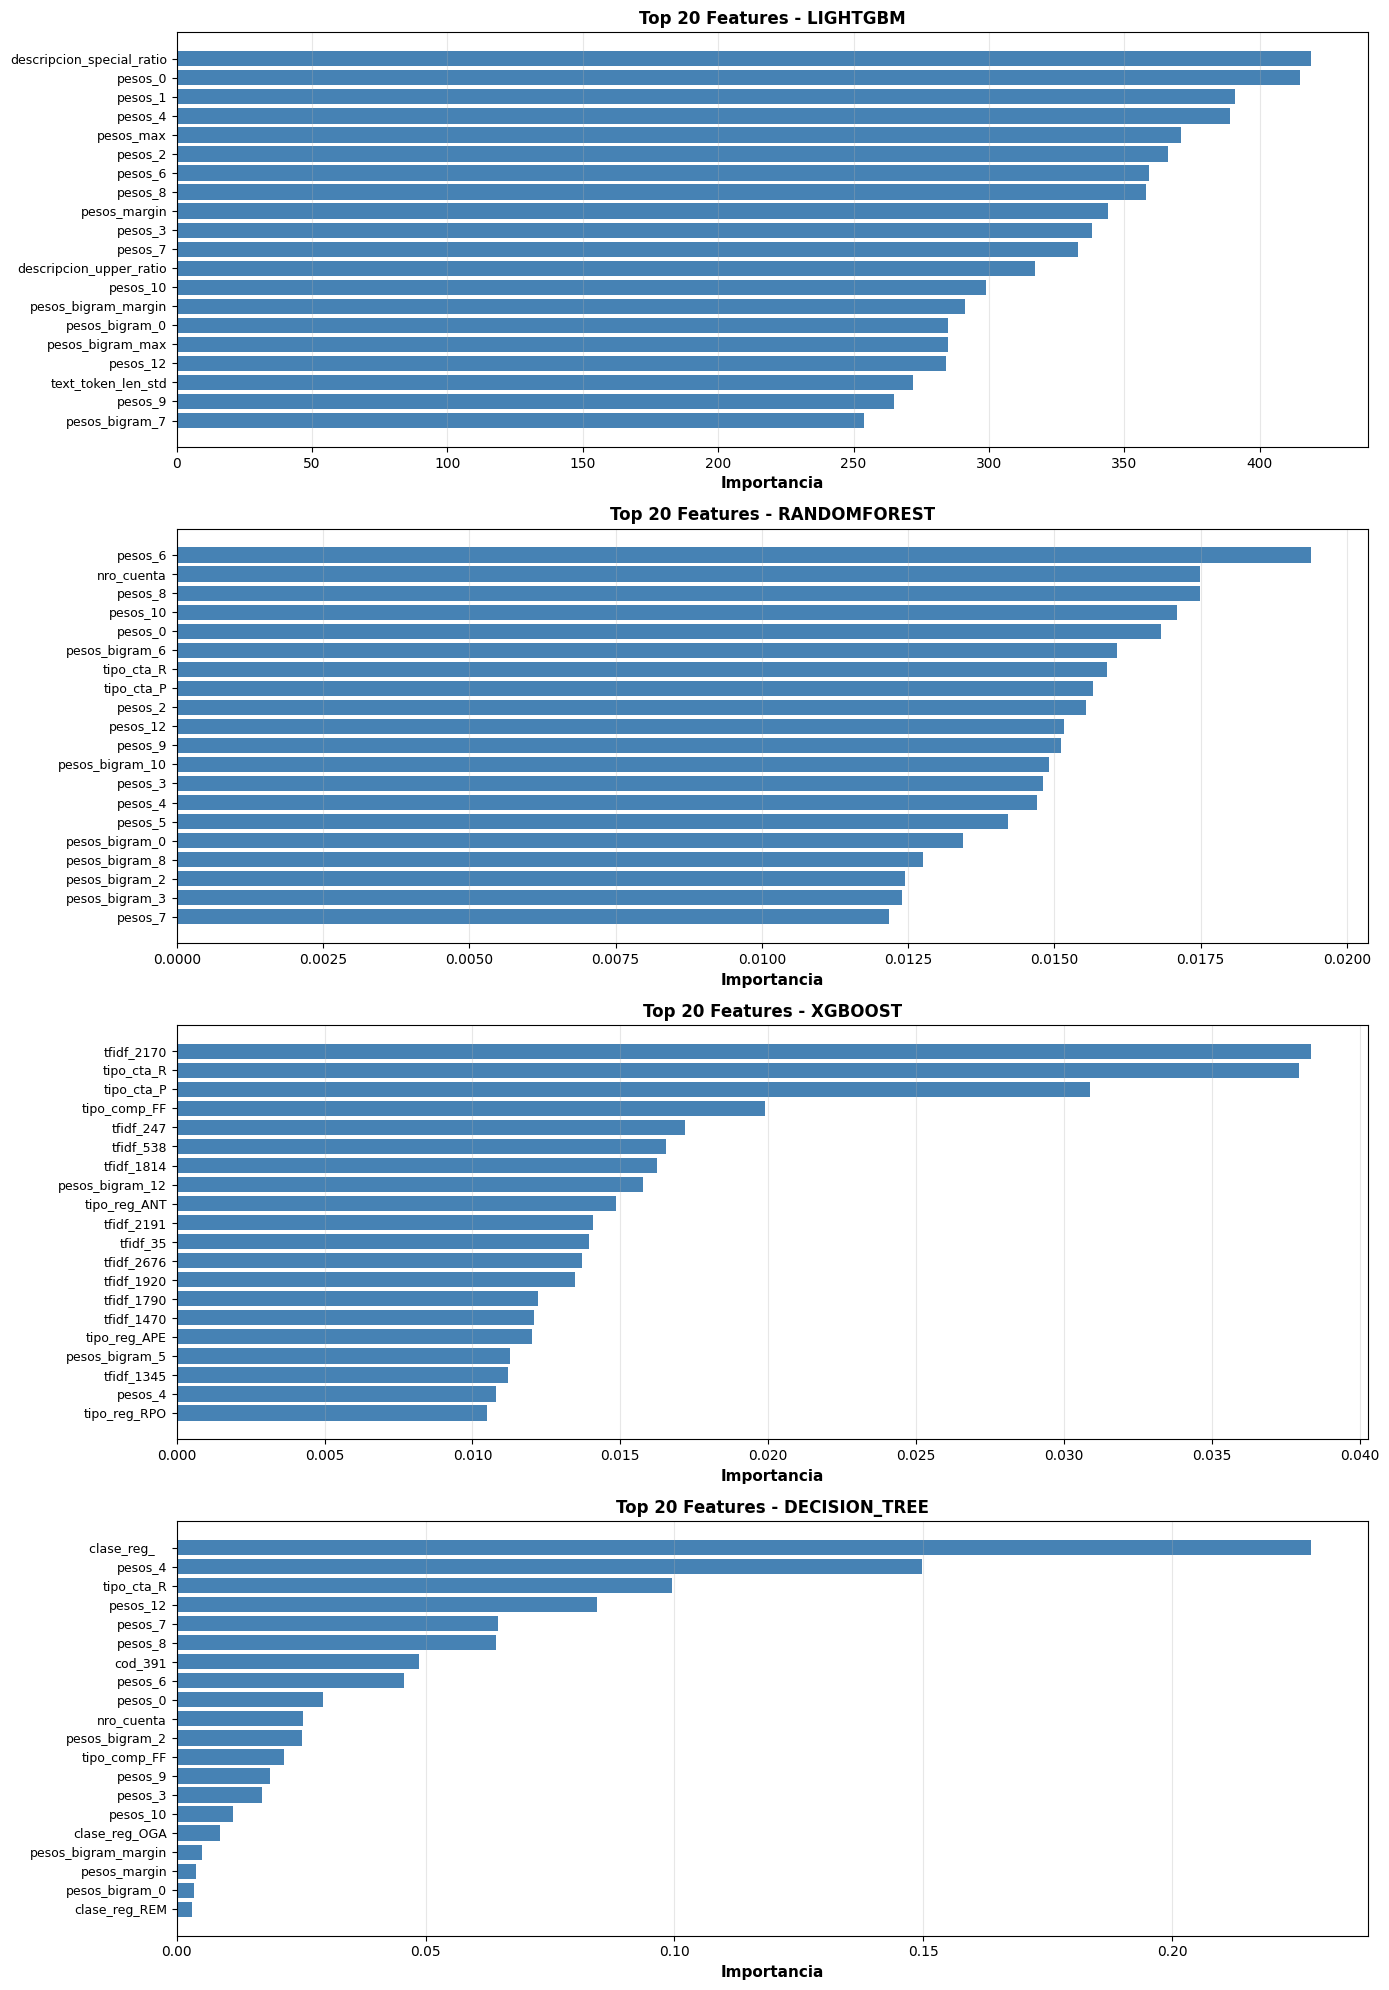


TOP 20 FEATURES POR MODELO

DECISION_TREE:
--------------------------------------------------------------------------------
            feature importance
      clase_reg_      0.227882
            pesos_4   0.149657
         tipo_cta_R   0.099492
           pesos_12   0.084517
            pesos_7   0.064573
            pesos_8   0.064072
            cod_391   0.048667
            pesos_6   0.045749
            pesos_0   0.029338
         nro_cuenta   0.025313
     pesos_bigram_2   0.025136
       tipo_comp_FF   0.021581
            pesos_9   0.018750
            pesos_3   0.017149
           pesos_10   0.011337
      clase_reg_OGA   0.008601
pesos_bigram_margin   0.005066
       pesos_margin   0.003809
     pesos_bigram_0   0.003433
      clase_reg_REM   0.003116

LIGHTGBM:
--------------------------------------------------------------------------------
                  feature importance
descripcion_special_ratio 419.000000
                  pesos_0 415.000000
                  pes

In [16]:
# Feature Importance de todos los modelos
feature_importance_all = {}
n_top_features = 20

for algo in ALGO_DIRS.keys():
    short_study, model_path = choose_study_and_model(
        algo, MANUAL_STUDIES.get(algo), studies_cache
    )
    
    if model_path is None or not Path(model_path).exists():
        print(f'[SKIP] {algo}: no se encontro modelo')
        continue
    
    try:
        model = joblib.load(model_path)
        
        if not hasattr(model, 'feature_importances_'):
            print(f'[SKIP] {algo}: no tiene atributo feature_importances_')
            continue
        
        feature_imp = model.feature_importances_
        
        # Crear DataFrame con feature importance
        imp_df = pd.DataFrame({
            'feature': feature_columns,
            'importance': feature_imp
        }).sort_values('importance', ascending=False)
        
        feature_importance_all[algo] = imp_df
        print(f'[OK] {algo}: {len(imp_df)} features extraídas')
        
    except Exception as e:
        print(f'[ERROR] {algo}: {e}')

# Visualizar feature importance para cada modelo
n_algos = len(feature_importance_all)
if n_algos > 0:
    fig, axes = plt.subplots(n_algos, 1, figsize=(14, 5 * n_algos))
    if n_algos == 1:
        axes = [axes]
    
    for idx, (algo, imp_df) in enumerate(feature_importance_all.items()):
        top_features = imp_df.head(n_top_features)
        
        axes[idx].barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features['feature'].values, fontsize=9)
        axes[idx].set_xlabel('Importancia', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Top {n_top_features} Features - {algo.upper()}', fontsize=12, fontweight='bold')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Mostrar tablas de top features por modelo
print("\n" + "="*100)
print("TOP 20 FEATURES POR MODELO")
print("="*100)
for algo, imp_df in sorted(feature_importance_all.items()):
    print(f"\n{algo.upper()}:")
    print("-" * 80)
    top_20 = imp_df.head(n_top_features)[['feature', 'importance']]
    top_20['importance'] = top_20['importance'].apply(lambda x: f"{x:.6f}")
    print(top_20.to_string(index=False))
print("="*100)
#fig.savefig("/home/francisco/maestria/trabajo_final/envios_profesor/importancia_1.png", dpi=300, bbox_inches='tight')

In [10]:
fig.savefig("/home/francisco/maestria/trabajo final/envios profesor/importancia_1.png",
            dpi=300, bbox_inches='tight')

# Reporte Comparativo de los 4 Modelos

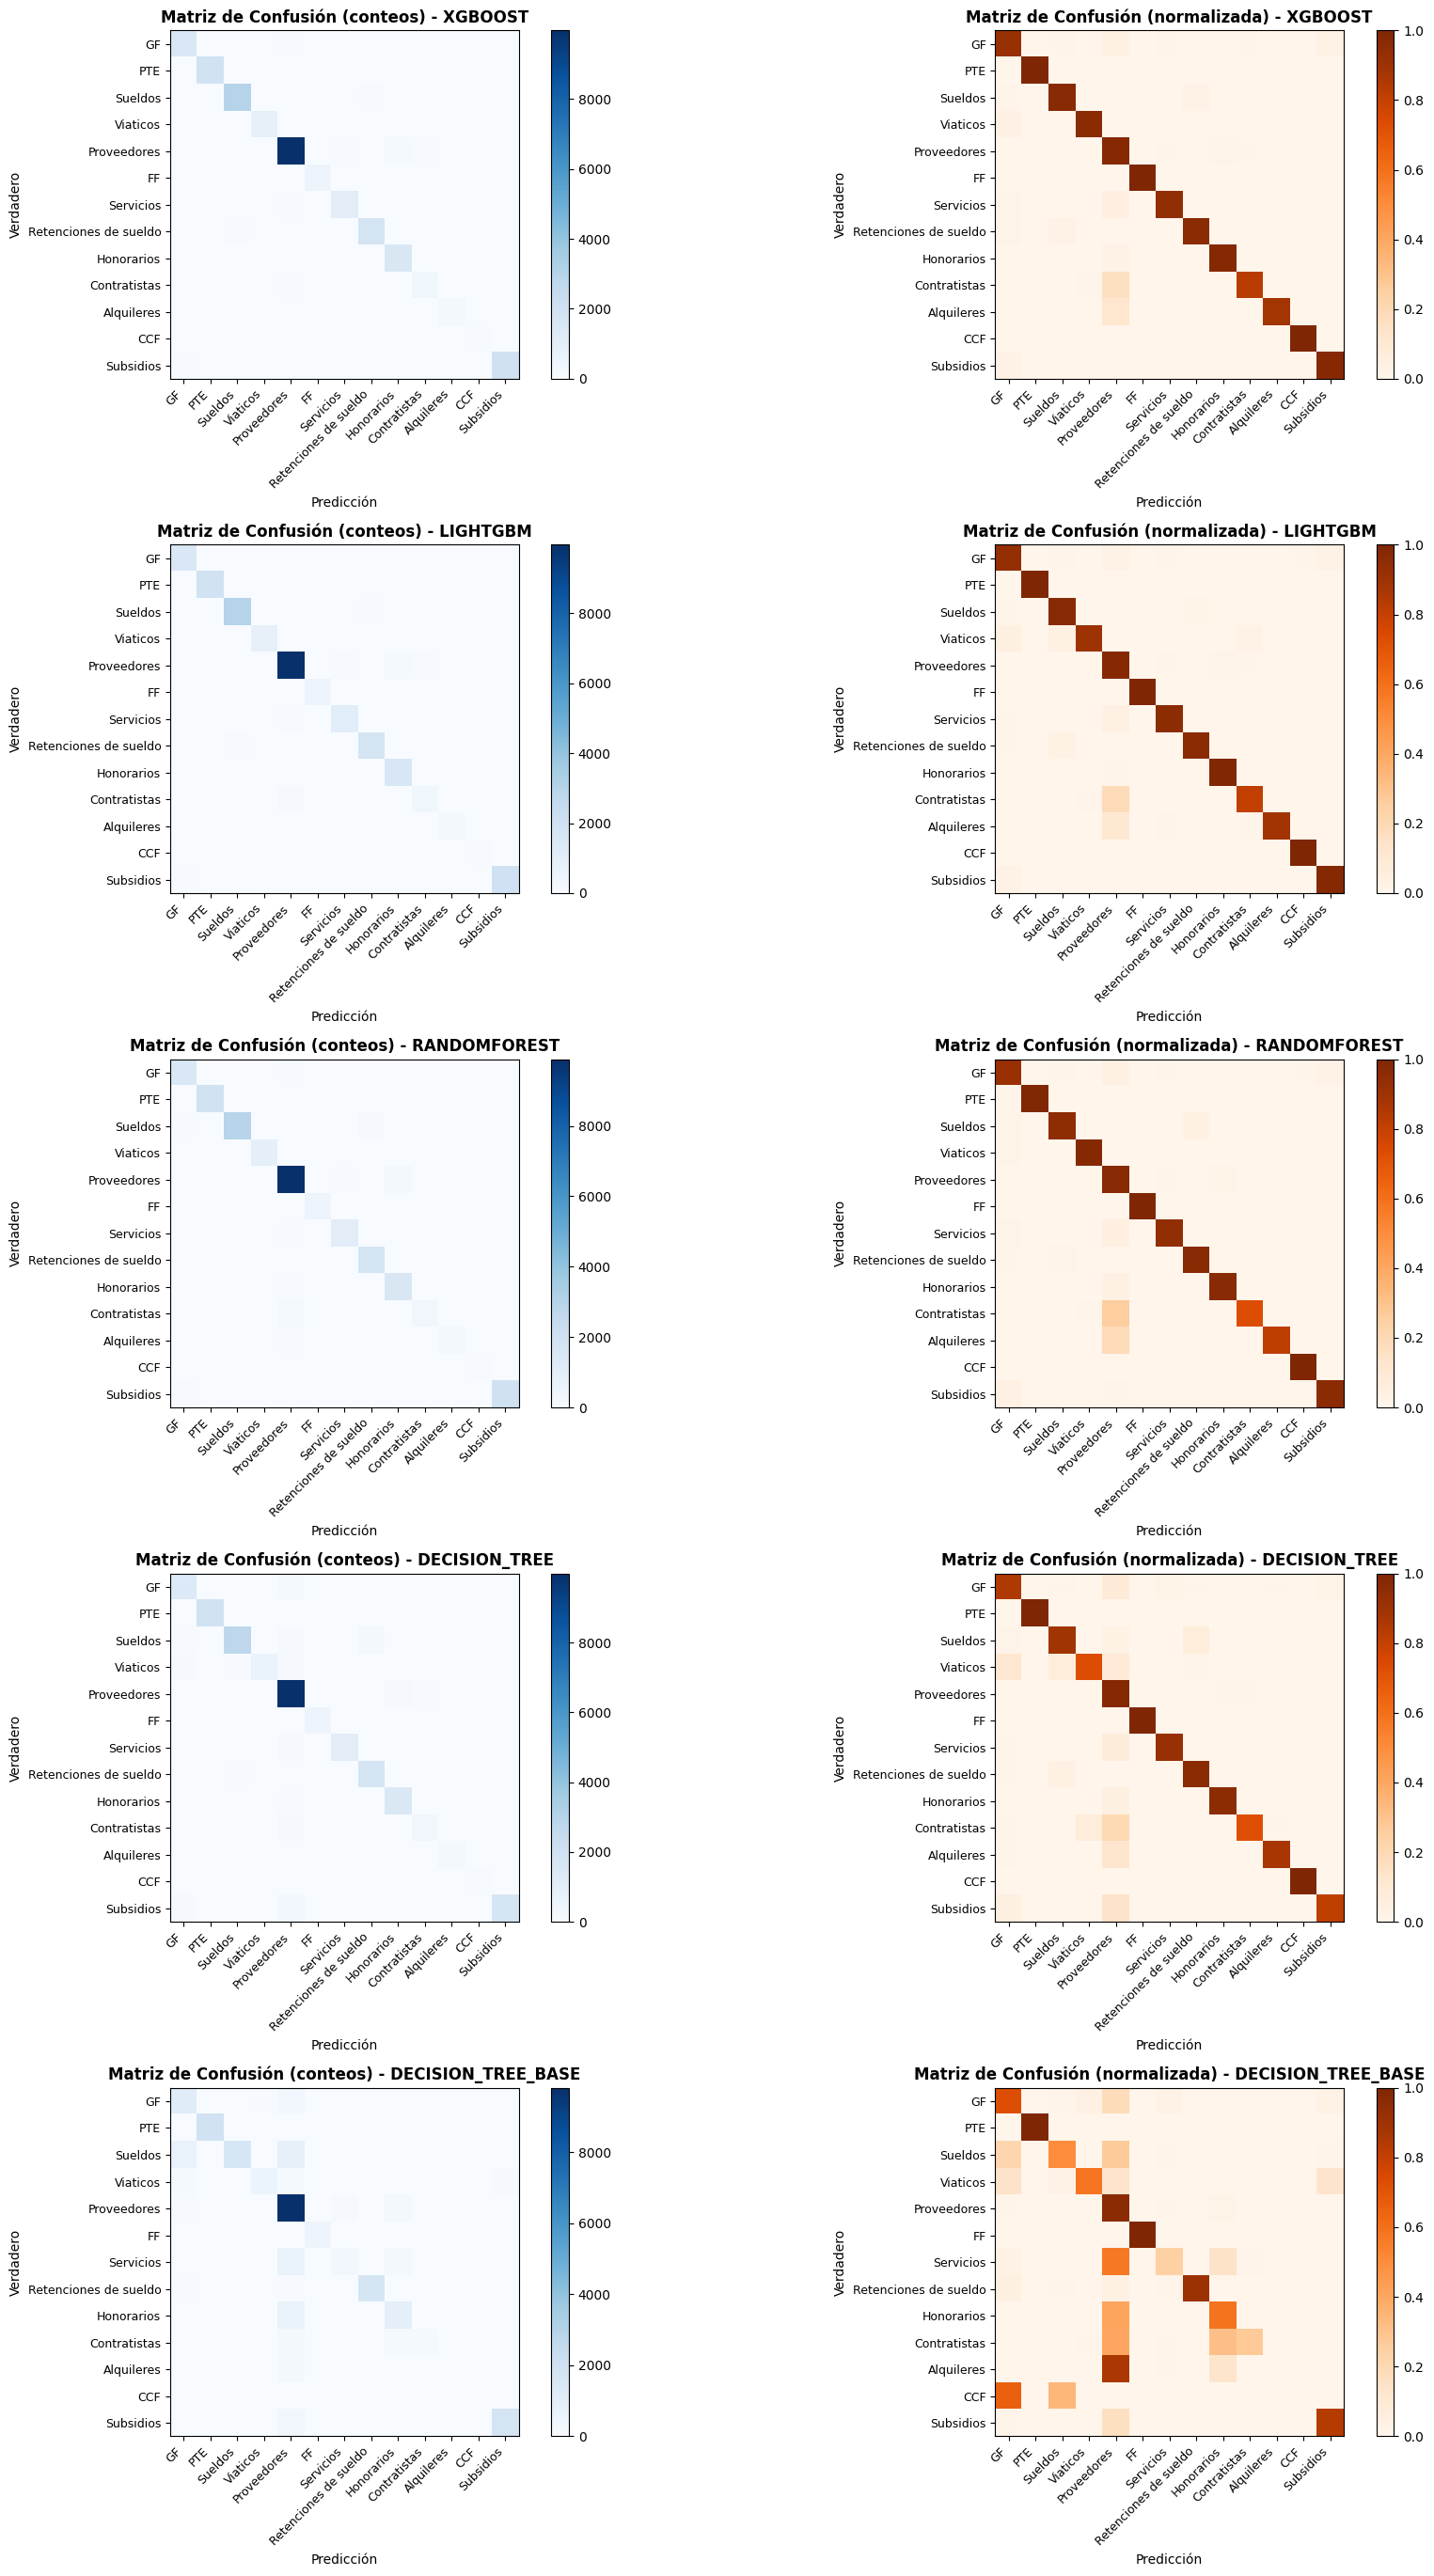

✓ Matrices de confusión generadas para los 4 modelos


In [17]:
# Matrices de confusión para los 4 modelos
n_models = len(results_df)
fig, axes = plt.subplots(n_models, 2, figsize=(18, 5.5 * n_models))

if n_models == 1:
    axes = axes.reshape(1, -1)

for idx, row in results_df.iterrows():
    algo = row['algorithm']
    y_pred_model = predictions_by_algo[algo]
    y_test_model = y_test_by_algo[algo]
    labels = labels_by_algo[algo]
    cm = cm_by_algo[algo]
    
    # Nombres de clases
    label_names = [class_names_dict.get(int(lbl), f"Clase_{lbl}") for lbl in labels]
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    
    # Matriz de conteos
    im0 = axes[idx, 0].imshow(cm, cmap='Blues')
    axes[idx, 0].set_title(f'Matriz de Confusión (conteos) - {algo.upper()}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Predicción', fontsize=10)
    axes[idx, 0].set_ylabel('Verdadero', fontsize=10)
    axes[idx, 0].set_xticks(np.arange(len(label_names)))
    axes[idx, 0].set_yticks(np.arange(len(label_names)))
    axes[idx, 0].set_xticklabels(label_names, rotation=45, ha='right', fontsize=9)
    axes[idx, 0].set_yticklabels(label_names, fontsize=9)
    plt.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04)
    
    # Matriz normalizada
    im1 = axes[idx, 1].imshow(cm_norm, cmap='Oranges', vmin=0, vmax=1)
    axes[idx, 1].set_title(f'Matriz de Confusión (normalizada) - {algo.upper()}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('Predicción', fontsize=10)
    axes[idx, 1].set_ylabel('Verdadero', fontsize=10)
    axes[idx, 1].set_xticks(np.arange(len(label_names)))
    axes[idx, 1].set_yticks(np.arange(len(label_names)))
    axes[idx, 1].set_xticklabels(label_names, rotation=45, ha='right', fontsize=9)
    axes[idx, 1].set_yticklabels(label_names, fontsize=9)
    plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
print("✓ Matrices de confusión generadas para los 4 modelos")

In [18]:
# Reportes de clasificación detallados para cada modelo
print("\n" + "="*100)
print("REPORTES DE CLASIFICACIÓN DETALLADOS - 4 MODELOS")
print("="*100)

classification_reports = {}

for idx, row in results_df.iterrows():
    algo = row['algorithm']
    y_pred_model = predictions_by_algo[algo]
    y_test_model = y_test_by_algo[algo]
    labels = labels_by_algo[algo]
    
    # Nombres de clases
    label_names = [class_names_dict.get(int(lbl), f"Clase_{lbl}") for lbl in labels]
    
    # Generar reporte
    report = classification_report(y_test_model, y_pred_model, target_names=label_names, 
                                   output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    classification_reports[algo] = report_df
    
    print(f"\n{'='*100}")
    print(f"MODELO: {algo.upper()} | Accuracy: {row['accuracy']:.4f} | Kappa: {row['kappa']:.4f}")
    print(f"{'='*100}")
    print(report_df.to_string())
    print()

print("="*100)


REPORTES DE CLASIFICACIÓN DETALLADOS - 4 MODELOS

MODELO: XGBOOST | Accuracy: 0.9668 | Kappa: 0.9582
                       precision    recall  f1-score       support
GF                      0.905934  0.921053  0.913431   1558.000000
PTE                     1.000000  1.000000  1.000000   1885.000000
Sueldos                 0.978375  0.966030  0.972163   3091.000000
Viaticos                0.983778  0.962585  0.973066    882.000000
Proveedores             0.976183  0.975419  0.975801  10211.000000
FF                      1.000000  1.000000  1.000000    473.000000
Servicios               0.942081  0.940379  0.941230   1107.000000
Retenciones de sueldo   0.961075  0.963716  0.962394   1819.000000
Honorarios              0.923926  0.976654  0.949559   1542.000000
Contratistas            0.866370  0.825902  0.845652    471.000000
Alquileres              0.976959  0.879668  0.925764    241.000000
CCF                     0.862745  1.000000  0.926316     44.000000
Subsidios               0.9

[LightGBM] [Warning] Unknown parameter: verbose_eval
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 0
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 0
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 1455
   - Clases encontradas (train): ['GF', 'PTE', 'Sueldos', 'Viaticos', 'Proveedores', 'FF', 'Servicios', 'Retenciones de sueldo', 'Honorarios', 'Contratistas', 'Alquileres', 'CCF', 'Subsidios']
   - Usando mapeo de clases existente: {'GF': 0, 'PTE': 1, 'Sueldos': 2, 'Viaticos': 3, 'Proveedores': 4, 'FF': 5, 'Servicios': 6, 'Retenciones de sueldo': 7, 'Honorarios': 8, 'Contratistas': 9, 'Alquileres': 10, 'CCF': 11, 'Subsidios': 12}
   - Usando mapeo de clases existente: {'GF': 0, 'PTE': 1, 'Sueldos': 2, 'Viaticos': 3, 'Proveedores': 4, 'FF': 5, 'Servicios': 6, 'Retenciones de sueldo': 7, 'Honorarios': 8, 'Contratistas': 9, 'Alquileres': 10, 'CCF': 11, 'Subsidios': 12}
   - Columnas para OneHotEncoding: ['tipo_comp', 'tipo_reg', 'clase_reg', 'tipo_cta', 'tipo_pres', 'd

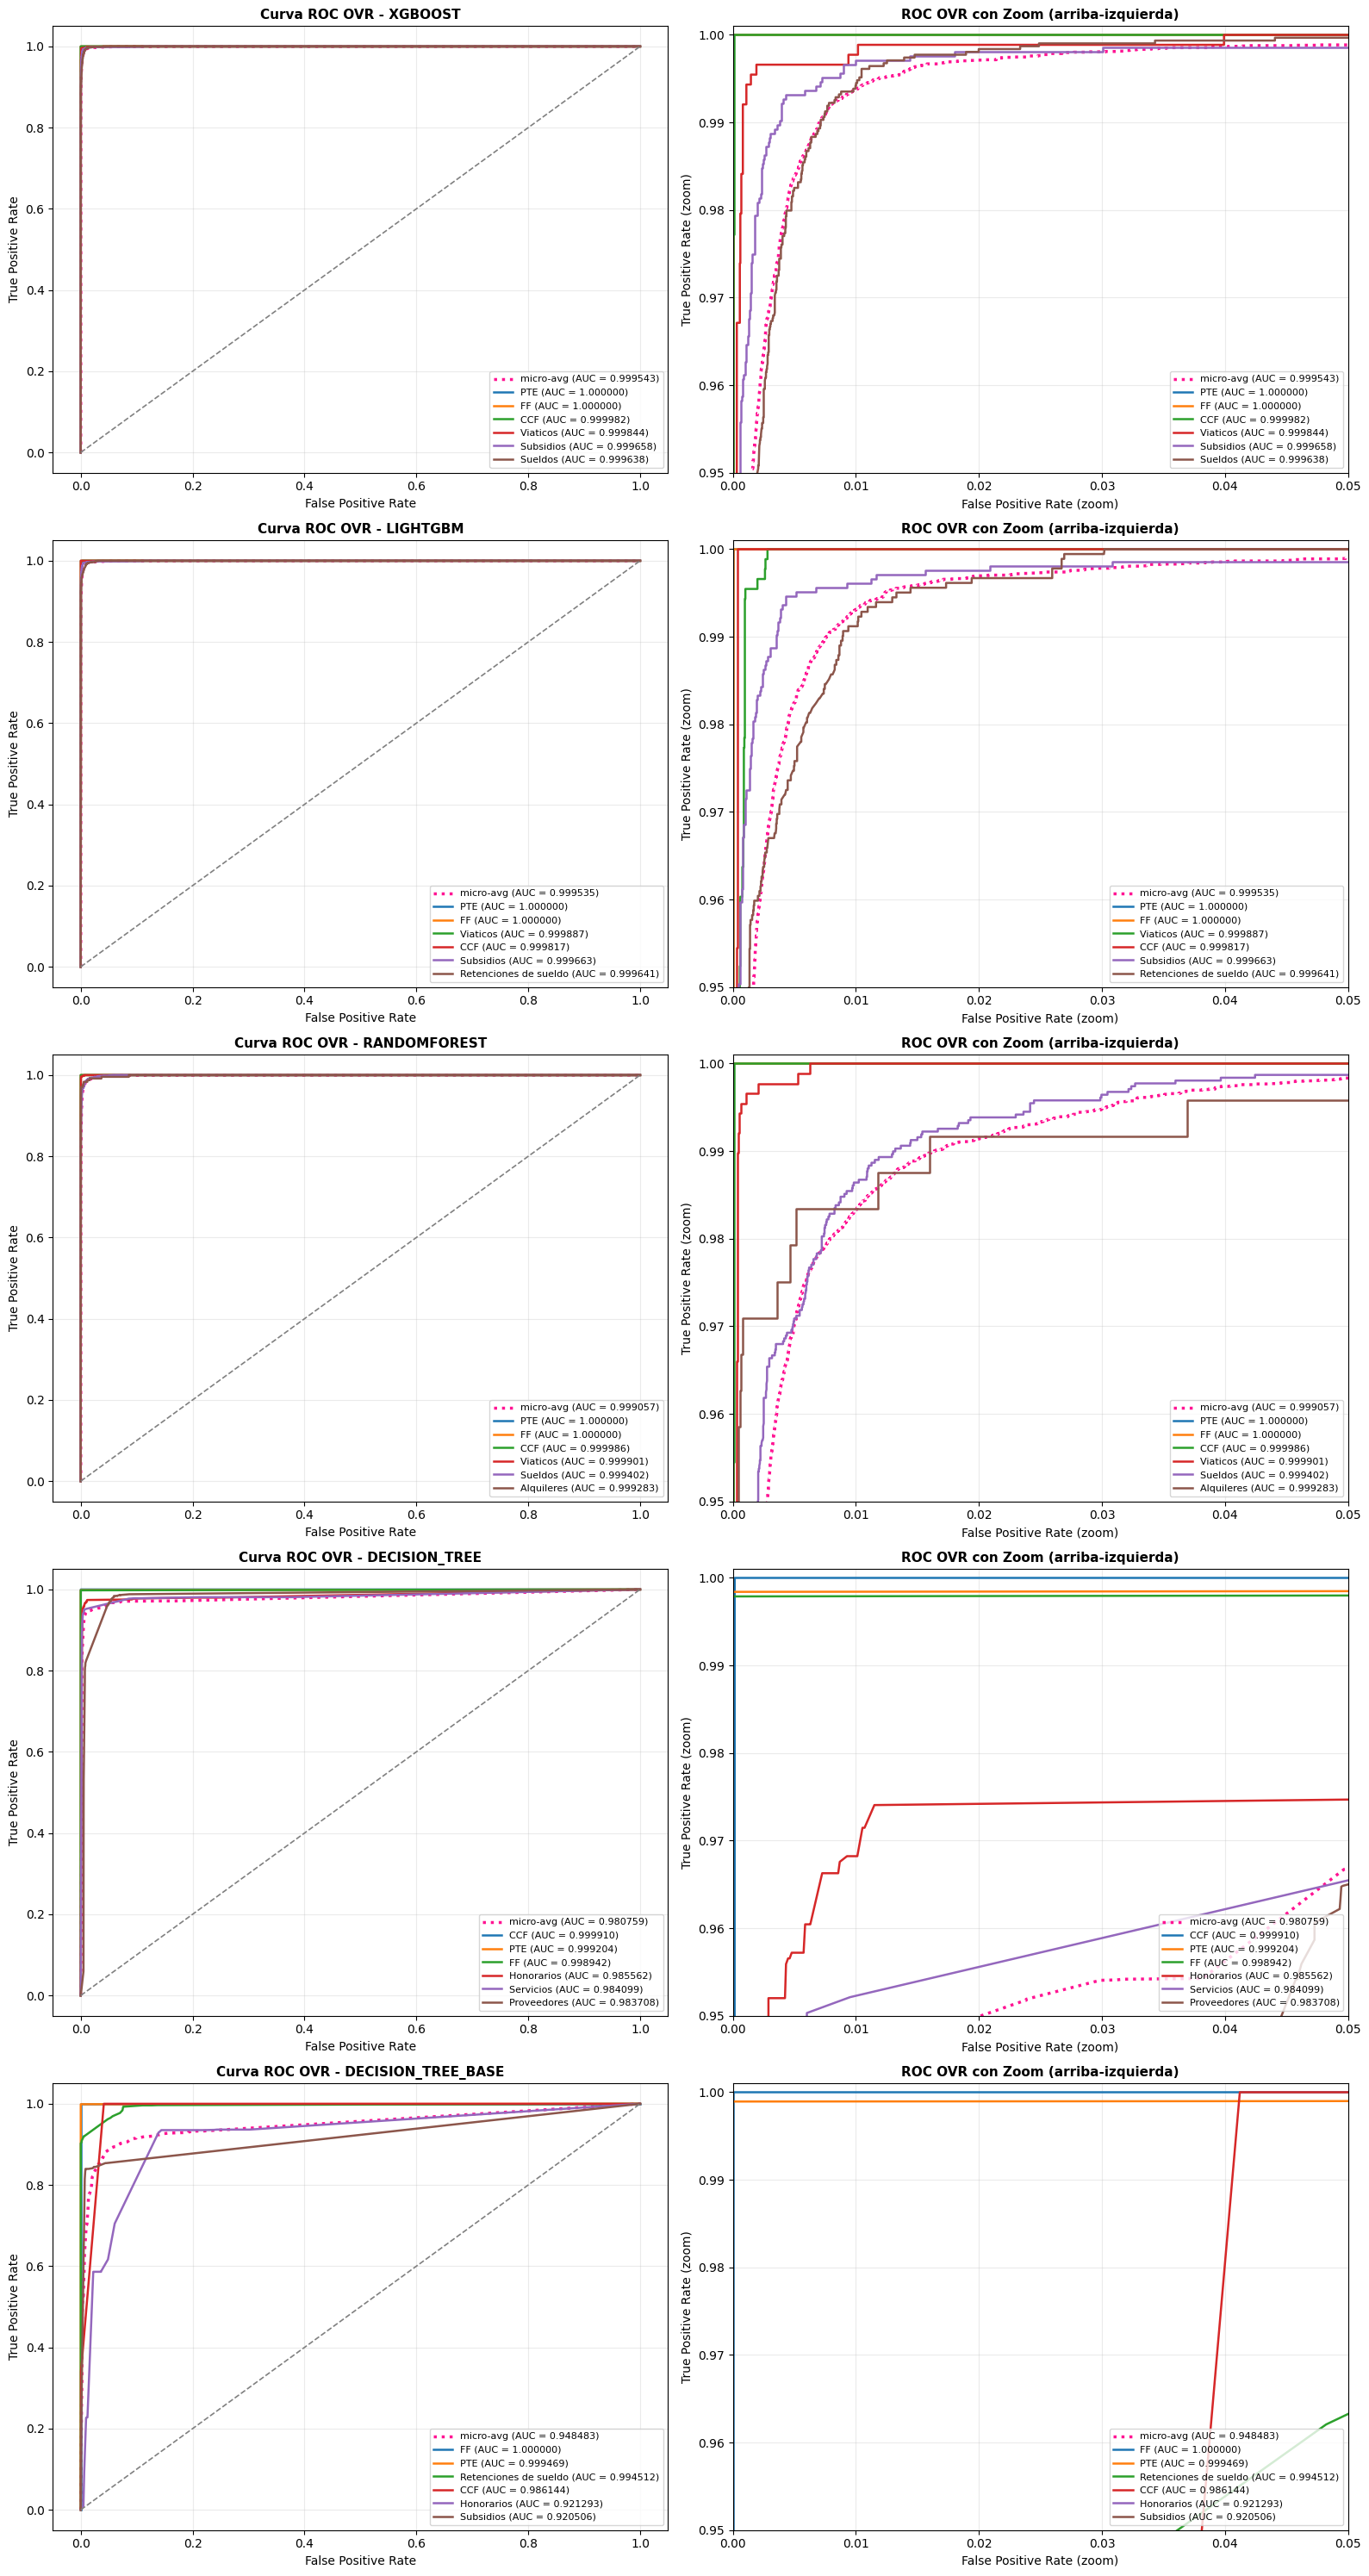

✓ Curvas ROC generadas para los 4 modelos


In [19]:
# Curvas ROC para los 4 modelos
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

zoom_fpr_max = 0.05
zoom_tpr_min = 0.95

n_models = len(results_df)
fig, axes = plt.subplots(n_models, 2, figsize=(16, 6 * n_models))

if n_models == 1:
    axes = axes.reshape(1, -1)

for idx, row in results_df.iterrows():
    algo = row['algorithm']
    short_study, model_path = choose_study_and_model(
        algo, MANUAL_STUDIES.get(algo), studies_cache
    )
    
    if model_path is None or not Path(model_path).exists():
        continue
    
    model = joblib.load(model_path)
    
    # Obtener X_test y y_test correctos para este modelo
    y_test_model = y_test_by_algo[algo]
    
    if algo == 'decision_tree_base':
        from preprocessing import ClassToInt, imputarNA, aplicar_ohe_splits
        REQUIRED_COLS = [
            "tipo_comp", "nro_cuenta", "nro_entidad", "desc_entidad", "tipo_pres",
            "tipo_reg", "clase_reg", "cod", "fuente_fin", "descripcion", "tipo_cta",
            "cod_bco", "Class"
        ]
        OHE_COLS = ['tipo_comp', 'tipo_reg', 'clase_reg', 'tipo_cta', 'tipo_pres', 'desc_entidad', 'cod_bco', 'cod']
        
        dfs_temp = {
            "train": pd.read_csv(DATASET_DIR / "2022-2023-2024.csv"),
            "val": pd.read_csv(DATASET_DIR / "2025-1.csv"),
            "test": pd.read_csv(DATASET_DIR / "2025-2.csv"),
        }
        for split in dfs_temp:
            dfs_temp[split] = dfs_temp[split][REQUIRED_COLS]
        for split in dfs_temp:
            dfs_temp[split] = imputarNA(dfs_temp[split])
        dfs_temp["train"], class_mapping_temp = ClassToInt(dfs_temp["train"], class_mapping=None)
        dfs_temp["val"], _ = ClassToInt(dfs_temp["val"], class_mapping=class_mapping_temp)
        dfs_temp["test"], _ = ClassToInt(dfs_temp["test"], class_mapping=class_mapping_temp)
        for split in dfs_temp:
            dfs_temp[split] = dfs_temp[split].drop("descripcion", axis=1)
        dfs_temp["train"], dfs_temp["val"], dfs_temp["test"] = aplicar_ohe_splits(
            dfs_temp["train"], dfs_temp["val"], dfs_temp["test"],
            columnas=OHE_COLS
        )
        X_test_model = dfs_temp["test"].drop("target", axis=1)
    else:
        X_test_model = X_test
    
    if not hasattr(model, 'predict_proba'):
        axes[idx, 0].text(0.5, 0.5, f'{algo}: sin predict_proba', ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'{algo}: sin predict_proba', ha='center', va='center')
        continue
    
    y_score = np.asarray(model.predict_proba(X_test_model))
    classes = np.unique(y_test_model)
    
    # ROC Binaria
    if len(classes) == 2:
        positive_class = classes[1]
        positive_class_name = class_names_dict.get(int(positive_class), f"Clase_{positive_class}")
        y_true_bin = (y_test_model.to_numpy() == positive_class).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_score[:, 1])
        roc_auc = auc(fpr, tpr)
        
        # Vista completa
        axes[idx, 0].plot(fpr, tpr, lw=2.5, label=f'ROC (AUC = {roc_auc:.6f})', color='#1f77b4')
        axes[idx, 0].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
        axes[idx, 0].set_xlabel('False Positive Rate', fontsize=10)
        axes[idx, 0].set_ylabel('True Positive Rate', fontsize=10)
        axes[idx, 0].set_title(f'ROC Completa - {algo.upper()}', fontsize=11, fontweight='bold')
        axes[idx, 0].legend(loc='lower right', fontsize=10)
        axes[idx, 0].grid(alpha=0.25)
        
        # Vista zoom
        axes[idx, 1].plot(fpr, tpr, lw=2.5, label=f'ROC (AUC = {roc_auc:.6f})', color='#1f77b4')
        axes[idx, 1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
        axes[idx, 1].set_xlim(0.0, zoom_fpr_max)
        axes[idx, 1].set_ylim(zoom_tpr_min, 1.001)
        axes[idx, 1].set_xlabel('False Positive Rate (zoom)', fontsize=10)
        axes[idx, 1].set_ylabel('True Positive Rate (zoom)', fontsize=10)
        axes[idx, 1].set_title('ROC con Zoom (arriba-izquierda)', fontsize=11, fontweight='bold')
        axes[idx, 1].legend(loc='lower right', fontsize=10)
        axes[idx, 1].grid(alpha=0.25)
    
    # ROC Multiclase OVR
    else:
        y_true_bin = label_binarize(y_test_model.to_numpy(), classes=classes)
        
        fpr_all = {}
        tpr_all = {}
        roc_auc_all = {}
        
        for i, cls in enumerate(classes):
            fpr_all[i], tpr_all[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
            roc_auc_all[i] = auc(fpr_all[i], tpr_all[i])
        
        fpr_all['micro'], tpr_all['micro'], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
        roc_auc_all['micro'] = auc(fpr_all['micro'], tpr_all['micro'])
        
        top_n = min(6, len(classes))
        top_classes = sorted(classes, key=lambda c: roc_auc_all[int(np.where(classes == c)[0][0])], reverse=True)[:top_n]
        
        # Vista completa
        axes[idx, 0].plot(
            fpr_all['micro'], tpr_all['micro'],
            label=f"micro-avg (AUC = {roc_auc_all['micro']:.6f})",
            color='deeppink', linestyle=':', linewidth=2.5,
        )
        for cls in top_classes:
            cls_idx = int(np.where(classes == cls)[0][0])
            class_name = class_names_dict.get(int(cls), f"Clase_{cls}")
            axes[idx, 0].plot(
                fpr_all[cls_idx], tpr_all[cls_idx],
                lw=1.8,
                label=f'{class_name} (AUC = {roc_auc_all[cls_idx]:.6f})'
            )
        axes[idx, 0].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
        axes[idx, 0].set_xlabel('False Positive Rate', fontsize=10)
        axes[idx, 0].set_ylabel('True Positive Rate', fontsize=10)
        axes[idx, 0].set_title(f'Curva ROC OVR - {algo.upper()}', fontsize=11, fontweight='bold')
        axes[idx, 0].legend(loc='lower right', fontsize=8)
        axes[idx, 0].grid(alpha=0.25)
        
        # Vista zoom
        axes[idx, 1].plot(
            fpr_all['micro'], tpr_all['micro'],
            label=f"micro-avg (AUC = {roc_auc_all['micro']:.6f})",
            color='deeppink', linestyle=':', linewidth=2.5,
        )
        for cls in top_classes:
            cls_idx = int(np.where(classes == cls)[0][0])
            class_name = class_names_dict.get(int(cls), f"Clase_{cls}")
            axes[idx, 1].plot(
                fpr_all[cls_idx], tpr_all[cls_idx],
                lw=1.8,
                label=f'{class_name} (AUC = {roc_auc_all[cls_idx]:.6f})'
            )
        axes[idx, 1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
        axes[idx, 1].set_xlim(0.0, zoom_fpr_max)
        axes[idx, 1].set_ylim(zoom_tpr_min, 1.001)
        axes[idx, 1].set_xlabel('False Positive Rate (zoom)', fontsize=10)
        axes[idx, 1].set_ylabel('True Positive Rate (zoom)', fontsize=10)
        axes[idx, 1].set_title('ROC OVR con Zoom (arriba-izquierda)', fontsize=11, fontweight='bold')
        axes[idx, 1].legend(loc='lower right', fontsize=8)
        axes[idx, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()
print("✓ Curvas ROC generadas para los 4 modelos")

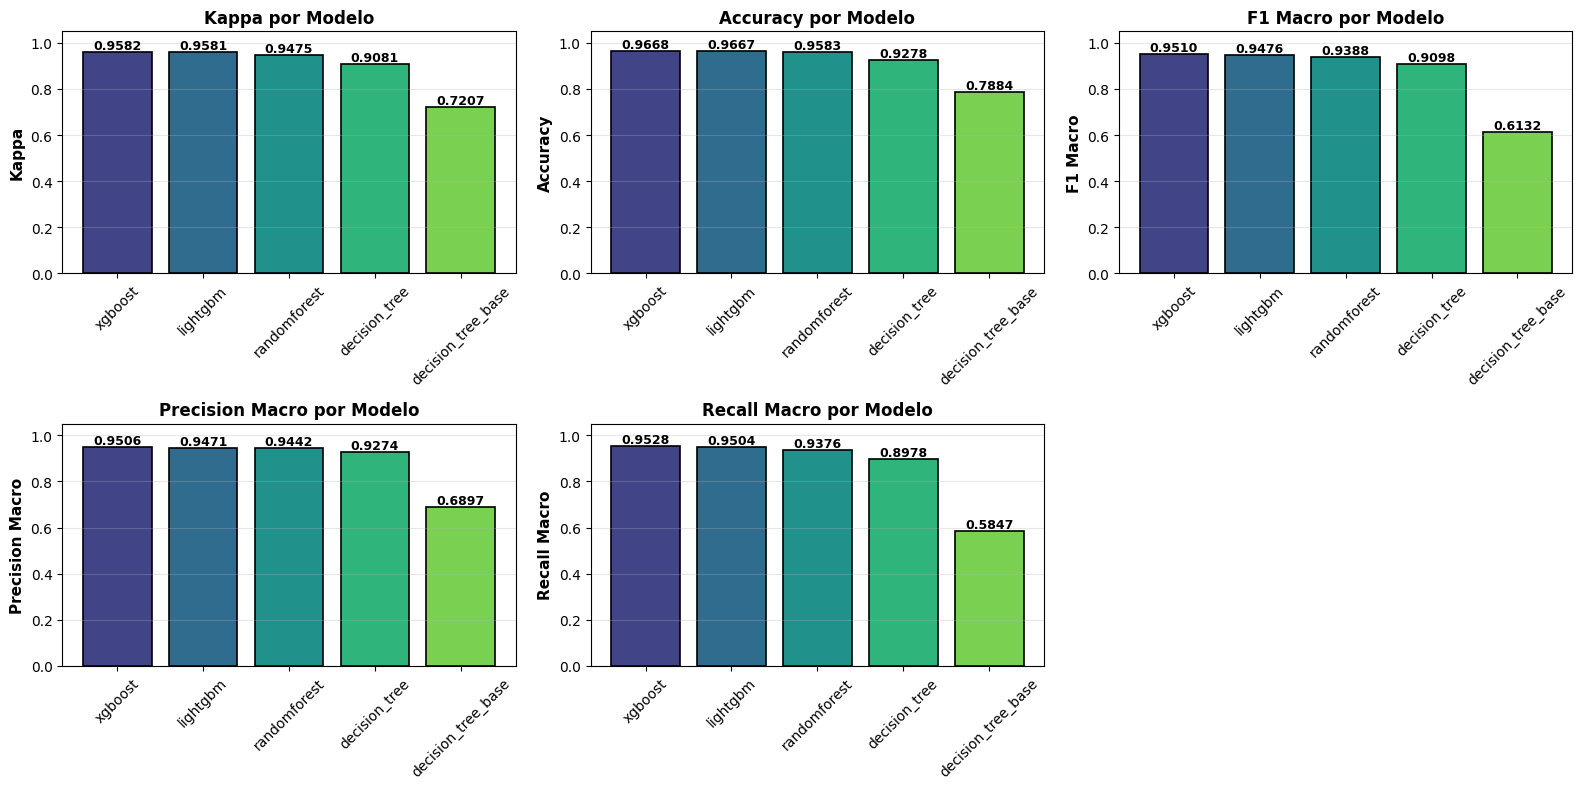


RESUMEN COMPARATIVO DE MÉTRICAS
         algorithm    kappa  accuracy  f1_macro  precision_macro  recall_macro
           xgboost 0.958212  0.966794  0.951013         0.950625      0.952794
          lightgbm 0.958138  0.966715  0.947615         0.947134      0.950387
      randomforest 0.947469  0.958276  0.938799         0.944224      0.937630
     decision_tree 0.908138  0.927752  0.909798         0.927360      0.897849
decision_tree_base 0.720672  0.788382  0.613243         0.689680      0.584667


In [20]:
# Comparación visual de métricas entre modelos
metrics_comparison = results_df[['algorithm', 'kappa', 'accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics_to_plot = ['kappa', 'accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = metrics_comparison[metric].values
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(values)))
    
    bars = ax.bar(metrics_comparison['algorithm'].values, values, color=colors, edgecolor='black', linewidth=1.2)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.replace("_", " ").title()} por Modelo', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Agregar valores en las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Remover la última subplot vacía
axes[1, 2].remove()

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("RESUMEN COMPARATIVO DE MÉTRICAS")
print("="*100)
print(metrics_comparison.to_string(index=False))
print("="*100)

In [21]:
# Guardar resultados en carpeta results
from datetime import datetime

# Crear carpeta results si no existe
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Timestamp para archivos
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# 1. Guardar métricas globales por modelo
metrics_global = results_df[['algorithm', 'study_name', 'accuracy', 'kappa', 'f1_macro', 'precision_macro', 'recall_macro']].copy()
metrics_global_path = RESULTS_DIR / f'metricas_globales_{timestamp}.csv'
metrics_global.to_csv(metrics_global_path, index=False)
print(f"✓ Guardado: {metrics_global_path}")

# 2. Guardar reportes de clasificación detallados por modelo
for algo, report_df in classification_reports.items():
    report_path = RESULTS_DIR / f'reporte_clasificacion_{algo}_{timestamp}.csv'
    report_df.to_csv(report_path)
    print(f"✓ Guardado: {report_path}")

# 3. Crear archivo consolidado con métricas por clase y modelo
consolidated_results = []

for idx, row in results_df.iterrows():
    algo = row['algorithm']
    y_pred_model = predictions_by_algo[algo]
    y_test_model = y_test_by_algo[algo]
    labels = labels_by_algo[algo]
    
    # Nombres de clases
    label_names = [class_names_dict.get(int(lbl), f"Clase_{lbl}") for lbl in labels]
    
    # Obtener reporte de clasificación
    report = classification_report(y_test_model, y_pred_model, target_names=label_names, 
                                   output_dict=True, zero_division=0)
    
    # Agregar por cada clase
    for class_name in label_names:
        if class_name in report:
            class_metrics = report[class_name]
            consolidated_results.append({
                'algorithm': algo,
                'class': class_name,
                'precision': class_metrics['precision'],
                'recall': class_metrics['recall'],
                'f1-score': class_metrics['f1-score'],
                'support': int(class_metrics['support']) if class_metrics['support'] > 0 else 0,
                'accuracy_global': row['accuracy'],
                'kappa_global': row['kappa'],
                'f1_macro_global': row['f1_macro'],
            })

consolidated_df = pd.DataFrame(consolidated_results)
consolidated_path = RESULTS_DIR / f'resultados_consolidados_{timestamp}.csv'
consolidated_df.to_csv(consolidated_path, index=False)
print(f"✓ Guardado: {consolidated_path}")

# 4. Guardar predicciones por modelo
for algo, y_pred in predictions_by_algo.items():
    y_test_model = y_test_by_algo[algo]
    predictions_data = pd.DataFrame({
        'y_true': y_test_model.values,
        'y_pred': y_pred.values,
        'correcto': (y_test_model.values == y_pred.values).astype(int)
    })
    pred_path = RESULTS_DIR / f'predicciones_{algo}_{timestamp}.csv'
    predictions_data.to_csv(pred_path, index=False)
    print(f"✓ Guardado: {pred_path}")

# 5. Guardar matrices de confusión en formato CSV
for algo, cm in cm_by_algo.items():
    labels = labels_by_algo[algo]
    label_names = [class_names_dict.get(int(lbl), f"Clase_{lbl}") for lbl in labels]
    
    cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
    cm_path = RESULTS_DIR / f'matriz_confusion_{algo}_{timestamp}.csv'
    cm_df.to_csv(cm_path)
    print(f"✓ Guardado: {cm_path}")

# 6. Guardar Feature Importance por modelo
for algo, imp_df in feature_importance_all.items():
    fi_path = RESULTS_DIR / f'feature_importance_{algo}_{timestamp}.csv'
    imp_df[['feature', 'importance']].to_csv(fi_path, index=False)
    print(f"✓ Guardado: {fi_path}")

# 7. Resumen ejecutivo
summary_data = []
for idx, row in results_df.iterrows():
    algo = row['algorithm']
    summary_data.append({
        'Modelo': algo,
        'Estudio': row['study_name'],
        'Accuracy': f"{row['accuracy']:.6f}",
        'Kappa': f"{row['kappa']:.6f}",
        'F1-Score Macro': f"{row['f1_macro']:.6f}",
        'Precisión Macro': f"{row['precision_macro']:.6f}",
        'Recall Macro': f"{row['recall_macro']:.6f}",
    })

summary_df = pd.DataFrame(summary_data)
summary_path = RESULTS_DIR / f'resumen_ejecutivo_{timestamp}.csv'
summary_df.to_csv(summary_path, index=False)
print(f"✓ Guardado: {summary_path}")

print(f"\n{'='*80}")
print(f"TODOS LOS RESULTADOS GUARDADOS EN: {RESULTS_DIR}")
print(f"{'='*80}")
print(f"\nArchivos generados:")
print(f"  • metricas_globales_{timestamp}.csv")
for algo in classification_reports.keys():
    print(f"  • reporte_clasificacion_{algo}_{timestamp}.csv")
print(f"  • resultados_consolidados_{timestamp}.csv")
for algo in predictions_by_algo.keys():
    print(f"  • predicciones_{algo}_{timestamp}.csv")
for algo in cm_by_algo.keys():
    print(f"  • matriz_confusion_{algo}_{timestamp}.csv")
for algo in feature_importance_all.keys():
    print(f"  • feature_importance_{algo}_{timestamp}.csv")
print(f"  • resumen_ejecutivo_{timestamp}.csv")
print(f"{'='*80}")

✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/metricas_globales_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/reporte_clasificacion_xgboost_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/reporte_clasificacion_lightgbm_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/reporte_clasificacion_randomforest_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/reporte_clasificacion_decision_tree_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/reporte_clasificacion_decision_tree_base_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/resultados_consolidados_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabajo final/tf-austral/results/predicciones_lightgbm_20260527_205636.csv
✓ Guardado: /home/francisco/maestria/trabaj